In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
happiness = pd.read_csv('../data/world_happiness.csv')
who = pd.read_csv('../data/who_physical_activity.csv')

print("Happiness shape:", happiness.shape)
print("WHO shape:", who.shape)
print()
print("=== Happiness columns ===")
print(happiness.columns.tolist())
print()
print("=== WHO columns ===")
print(who.columns.tolist())

Happiness shape: (158, 12)
WHO shape: (194, 13)

=== Happiness columns ===
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

=== WHO columns ===
['Country', 'Total Population (2022)', 'Population Aged < 20 (%)', 'Population Aged > 60 (%)', 'Deaths Due to NCD', 'World Bank Income Group', 'GDP per capita (INT$)', 'Physical Inactivity, Adolescents Aged 11-17 (%), Male', 'Physical Inactivity, Adolescents Aged 11-17 (%), Female', 'Physical Inactivity, Adults Aged 18+ (%), Male', 'Physical Inactivity, Adults Aged 18+ (%), Female', 'Physical Inactivity, Adults Aged 70+ (%), Male', 'Physical Inactivity, Adults Aged 70+ (%), Female']


In [4]:
# Merge datasets on Country
df = pd.merge(happiness, who, on='Country', how='inner')

print("Merged shape:", df.shape)
print()
print("Missing values:")
print(df.isnull().sum())

Merged shape: (131, 24)

Missing values:
Country                                                     0
Region                                                      0
Happiness Rank                                              0
Happiness Score                                             0
Standard Error                                              0
Economy (GDP per Capita)                                    0
Family                                                      0
Health (Life Expectancy)                                    0
Freedom                                                     0
Trust (Government Corruption)                               0
Generosity                                                  0
Dystopia Residual                                           0
Total Population (2022)                                     0
Population Aged < 20 (%)                                    0
Population Aged > 60 (%)                                    0
Deaths Due to NCD            

In [5]:
# WHO columns have % signs as strings, convert to float
who_cols = [
    'Physical Inactivity, Adolescents Aged 11-17 (%), Male',
    'Physical Inactivity, Adolescents Aged 11-17 (%), Female',
    'Physical Inactivity, Adults Aged 18+ (%), Male',
    'Physical Inactivity, Adults Aged 18+ (%), Female',
    'Physical Inactivity, Adults Aged 70+ (%), Male',
    'Physical Inactivity, Adults Aged 70+ (%), Female'
]

for col in who_cols:
    df[col] = df[col].astype(str).str.replace('%', '').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values with column mean
df[who_cols] = df[who_cols].fillna(df[who_cols].mean())

# Create average physical inactivity column
df['Avg Inactivity Adults'] = df[[
    'Physical Inactivity, Adults Aged 18+ (%), Male',
    'Physical Inactivity, Adults Aged 18+ (%), Female'
]].mean(axis=1)

print("Done! Sample:")
print(df[['Country', 'Happiness Score', 'Avg Inactivity Adults']].head(10))

Done! Sample:
       Country  Happiness Score  Avg Inactivity Adults
0  Switzerland            7.587               24.00000
1      Iceland            7.561               28.71875
2      Denmark            7.527               28.50000
3       Norway            7.522               32.00000
4       Canada            7.427               28.50000
5      Finland            7.406               16.50000
6  Netherlands            7.378               27.00000
7       Sweden            7.364               23.50000
8  New Zealand            7.286               42.00000
9       Israel            7.278               28.71875


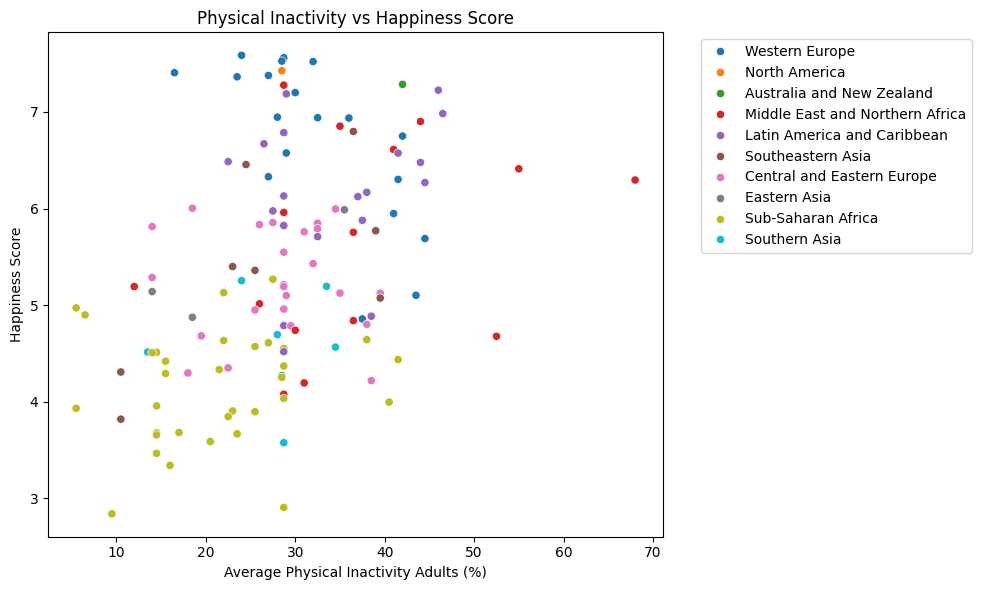

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Avg Inactivity Adults', y='Happiness Score', hue='Region')

plt.title('Physical Inactivity vs Happiness Score')
plt.xlabel('Average Physical Inactivity Adults (%)')
plt.ylabel('Happiness Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../reports/inactivity_vs_happiness.png', dpi=150)
plt.show()


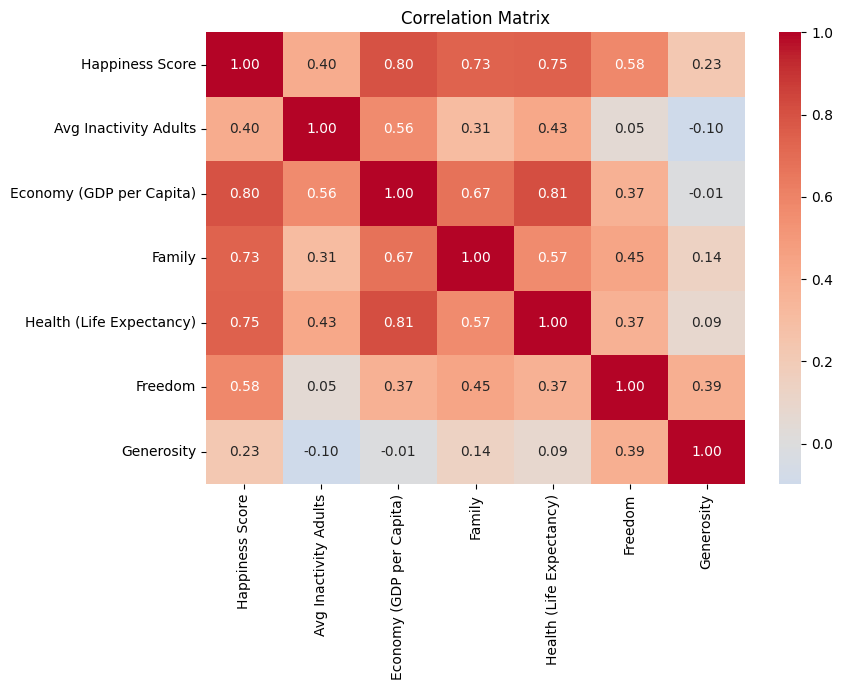

In [7]:
# Correlation matrix
corr_cols = ['Happiness Score', 'Avg Inactivity Adults', 
             'Economy (GDP per Capita)', 'Family', 
             'Health (Life Expectancy)', 'Freedom', 'Generosity']

corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png', dpi=150)
plt.show()